In [17]:
import pandas as pd
from pprint import pprint
from bs4 import BeautifulSoup
import io

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns',None) #display all columns
pd.set_option('display.max_rows',None) #display all rows

groups_pts_src_map = {'group_1': 'cricketxi', 'group_2': 'iplt20'}
groups_team_wins_pts_map = {'group_1': 100, 'group_2': 50}
groups_team_nr_pts_map = {'group_1': 50, 'group_2': 25}
playoffs_wins_map = {'Royal Challengers Bengaluru': 1, 'Gujarat Titans': 1, 'Rajasthan Royals': 1}
# Required Input files
# When running for the very first time, `ipl2025_results.csv`` file is required with all the team managers and an initial row of 0s.
# IPL2025MockAuctionSummary.csv file is required with each of the managers, their teams and their players listed.

# Dependencies to install
#  pip3 install beautifulsoup4
#  pip3 install lxml ??? (Double check if required)
#  pip3 install html5lib ??? (Double check if required)
#  pip3 install pywhatkit
#  pip3 install matplotlib
#  pip3 install selenium
#  pip3 install tabulate

In [2]:
import sys
from datetime import date

# Backup the input and output files for each day for posterity

# Change for each day
ipl_day_0 = date(2026, 3, 27)
ipl_day_cur = date.today()
day_num = abs((ipl_day_cur - ipl_day_0).days)
day_num = 19
day = 'day_' + str(day_num)
prev_day = 'day_' + str(day_num - 1)
print(day_num)

# Change for each group
group = sys.argv[1]
group = 'group_2'
group_pts_source = groups_pts_src_map[group]
group_team_win_pts = groups_team_wins_pts_map[group]
group_team_nr_pts = groups_team_nr_pts_map[group]
print(group)
print(group_pts_source)
tournament = 'ipl_2026'
results_file = f'./{group}/{tournament}_results_{day}.csv'
prev_results_file = f'./{group}/{tournament}_results_{prev_day}.csv'
leaderboard_graph_file = f'./{group}/{tournament}_leaderboard.png'
leaderboard_file = f'./{group}/{tournament}_leaderboard.txt'

ipl_mock_auction_summary = f'./{group}/AuctionSummary.csv'

19
group_2
iplt20


In [3]:
mvp_df = pd.read_csv(f'./data/{group_pts_source}/mvp_{day}.csv')
mvp_df

,POS,Player,Pts,Mat,Wkts,Dots,4s,6s,Catches,Run outs,Stumpings,Team
0,1,anshul kamboj,127.0,5,10,43,2,1,1,0.0,0,CSK
1,2,ishan kishan,122.5,5,0,0,22,12,4,7.0,1,SRH
2,3,rajat patidar,119.5,5,0,0,12,21,4,0.0,0,RCB
3,4,prasidh krishna,118.5,4,10,40,0,0,1,0.0,0,GT
4,5,vaibhav sooryavanshi,114.0,5,0,0,18,18,0,0.0,0,RR
5,6,prince yadav,112.5,5,9,44,0,0,1,0.0,0,LSG
6,7,jofra archer,112.5,5,7,49,0,0,3,7.0,0,RR
7,8,dhruv jurel,104.5,5,0,0,17,8,7,10.5,0,RR
8,9,ravi bishnoi,104.0,5,9,28,0,0,4,0.0,0,RR
9,10,virat kohli,104.0,5,0,0,25,8,3,0.0,0,RCB


In [4]:
# For group_2 (iplt20 source), recalculate Pts using our own scoring rules:
# 3.5 pts per wicket, 3.5 pts per six
# 2.5 pts per four, catch, or stumping
# 1 pt per dot ball
# 1 pt per run out (Run outs column stores iplt20 points at 3.5/run out, so divide by 3.5 to get count)
if group_pts_source == 'iplt20':
    mvp_df['Pts'] = (
        mvp_df['Wkts'] * 3.5 +
        mvp_df['6s'] * 3.5 +
        mvp_df['4s'] * 2.5 +
        mvp_df['Catches'] * 2.5 +
        mvp_df['Stumpings'] * 2.5 +
        mvp_df['Dots'] * 1 +
        (mvp_df['Run outs'] / 0.5) * 1
    )
mvp_df

,POS,Player,Pts,Mat,Wkts,Dots,4s,6s,Catches,Run outs,Stumpings,Team
0,1,anshul kamboj,89.0,5,10,43,2,1,1,0.0,0,CSK
1,2,ishan kishan,123.5,5,0,0,22,12,4,7.0,1,SRH
2,3,rajat patidar,113.5,5,0,0,12,21,4,0.0,0,RCB
3,4,prasidh krishna,77.5,4,10,40,0,0,1,0.0,0,GT
4,5,vaibhav sooryavanshi,108.0,5,0,0,18,18,0,0.0,0,RR
5,6,prince yadav,78.0,5,9,44,0,0,1,0.0,0,LSG
6,7,jofra archer,95.0,5,7,49,0,0,3,7.0,0,RR
7,8,dhruv jurel,109.0,5,0,0,17,8,7,10.5,0,RR
8,9,ravi bishnoi,69.5,5,9,28,0,0,4,0.0,0,RR
9,10,virat kohli,98.0,5,0,0,25,8,3,0.0,0,RCB


In [5]:
fantasy_teams_auction_df = pd.read_csv(ipl_mock_auction_summary)
fantasy_teams_auction_df

,Kumar & Akash,Vasan,Manav & Sri,Vasanth,Raghav,Arvindh,Niranjani,Mira & Arjun,Sriram V
0,Gujarat Titans,Rajasthan Royals,Royal Challengers Bengaluru,Chennai Super Kings,Sunrisers Hyderabad,Kolkata Knight Riders,Delhi Capitals,Punjab Kings,Mumbai Indians
1,Shubman Gill,Yashasvi Jaiswal,Virat Kohli,Sanju Samson,Travis Head,Sunil Narine,K L Rahul,Tilak Varma,Rohit Sharma
2,Luhan Dre Pretorious,Shimron Hetmyer,Rajat Patidar,Ruturaj Gaikwad,Abhishek Sharma,Varun Chakaravarthy,Axar Patel,Shreyas Iyer,Surya kumar Yadav
3,Anshul Kamboj,Ravindra Jadeja,Jacob Bethell,Dewald Brevis,Ishan Kishan,Mukesh Kumar,Tristan Stubbs,Marco Jansen,Quinton De Kock
4,Noor Ahmad,Mohammed Siraj,Sai Sudharsan,Vyshak Vijaykumar,Prabhsimran Singh,Dhruv Jurel,Digvesh Singh,Yuzvendra Chahal,Mitchell Santner
5,Mohammad Shami,Khaleel Ahmed,Mitchell Starc,Jacob Duffy,Romario Shepherd,Rahul Tewatia,Trent Boult,Aniket Verma,Ryan Rickelton
6,Rashid Khan,Vaibhav Arora,Shivam Dube,Suyash Sharma,Tushar Deshpande,Matt Henry,Glenn Phillips,Jasprit Bumrah,Akash Singh
7,Finn Allen,M S Dhoni,Kartik Tyagi,Rishabh Pant,Kagiso Rabada,Mayank Yadav,Aiden Markram,Ravi Bishnoi,Ashutosh Sharma
8,Naman Dhir,Jamie Overton,Nicholas Pooran,T Natarajan,Venkatesh Iyer,Shahrukh Khan,Kuldeep Yadav,Priyansh Arya,Mitchell Marsh
9,Prasidh Krishna,Pathum Nissanka,Arshad Khan,Arshdeep Singh,Mayank Markande,Cameron Green,Vipraj Nigam,Prithvi Shaw,Ayush Mhatre


In [6]:
fantasy_mgrs = fantasy_teams_auction_df.columns
fantasy_mgrs.to_list()

['Kumar & Akash',
 'Vasan',
 'Manav & Sri',
 'Vasanth',
 'Raghav',
 'Arvindh',
 'Niranjani',
 'Mira & Arjun',
 'Sriram V']

In [7]:
#Make new dataframe for manager_teams 
fantasy_mgr_teams = fantasy_teams_auction_df.iloc[:1]
fantasy_mgr_teams

,Kumar & Akash,Vasan,Manav & Sri,Vasanth,Raghav,Arvindh,Niranjani,Mira & Arjun,Sriram V
0,Gujarat Titans,Rajasthan Royals,Royal Challengers Bengaluru,Chennai Super Kings,Sunrisers Hyderabad,Kolkata Knight Riders,Delhi Capitals,Punjab Kings,Mumbai Indians


In [8]:
import os
#Create new dataframe for manager_players
fantasy_teams_df = fantasy_teams_auction_df.iloc[1:]
fantasy_teams_df = fantasy_teams_df.apply(lambda x: x.astype(str).str.lower())

fantasy_teams_df_per_mgr = {}
for mgr in fantasy_teams_df.columns:
    mgr_file = f'./{group}/{mgr}.csv'
    if not os.path.exists(mgr_file):
        df = pd.DataFrame(fantasy_teams_df[mgr])
        df.to_csv(mgr_file, index=False)
    else:
        df = pd.read_csv(mgr_file)
    fantasy_teams_df_per_mgr[mgr] = df
fantasy_teams_df


,Kumar & Akash,Vasan,Manav & Sri,Vasanth,Raghav,Arvindh,Niranjani,Mira & Arjun,Sriram V
1,shubman gill,yashasvi jaiswal,virat kohli,sanju samson,travis head,sunil narine,k l rahul,tilak varma,rohit sharma
2,luhan dre pretorious,shimron hetmyer,rajat patidar,ruturaj gaikwad,abhishek sharma,varun chakaravarthy,axar patel,shreyas iyer,surya kumar yadav
3,anshul kamboj,ravindra jadeja,jacob bethell,dewald brevis,ishan kishan,mukesh kumar,tristan stubbs,marco jansen,quinton de kock
4,noor ahmad,mohammed siraj,sai sudharsan,vyshak vijaykumar,prabhsimran singh,dhruv jurel,digvesh singh,yuzvendra chahal,mitchell santner
5,mohammad shami,khaleel ahmed,mitchell starc,jacob duffy,romario shepherd,rahul tewatia,trent boult,aniket verma,ryan rickelton
6,rashid khan,vaibhav arora,shivam dube,suyash sharma,tushar deshpande,matt henry,glenn phillips,jasprit bumrah,akash singh
7,finn allen,m s dhoni,kartik tyagi,rishabh pant,kagiso rabada,mayank yadav,aiden markram,ravi bishnoi,ashutosh sharma
8,naman dhir,jamie overton,nicholas pooran,t natarajan,venkatesh iyer,shahrukh khan,kuldeep yadav,priyansh arya,mitchell marsh
9,prasidh krishna,pathum nissanka,arshad khan,arshdeep singh,mayank markande,cameron green,vipraj nigam,prithvi shaw,ayush mhatre
10,hardik pandya,liam livingstone,pat cummins,avesh khan,salil arora,phil salt,krunal pandya,harsh dubey,nitish rana


In [9]:
from thefuzz import fuzz
from thefuzz import process
            
# Compute total score for each fantasy team based on MVP points of each player
scores = { fantasy_mgr:0 for fantasy_mgr in fantasy_mgrs.to_list() }
for mgr in fantasy_mgrs:
    print(mgr)
    mgr_df = fantasy_teams_df_per_mgr[mgr]
    mgr_day_pts = {}
    mgr_file = f'./{group}/{mgr}.csv'
    all_players_have_min_pts = True
    mvp_players_with_pts = mvp_df['Player'].to_list()
    for i in range(len(fantasy_teams_df[mgr])):
        player_name = str(fantasy_teams_df[mgr].iloc[i]).lower()
        if player_name in mvp_players_with_pts:
            player_score = float(mvp_df.loc[mvp_df['Player'] == fantasy_teams_df[mgr].iloc[i],'Pts'].iloc[0])
            scores[mgr] += player_score
            mgr_day_pts[player_name] = player_score
            print(f'\t{player_name} points found. Adding his score {player_score} to total. New score {scores[mgr]}')
        else:
            closest_match = process.extractOne(player_name, mvp_players_with_pts)
            mgr_day_pts[player_name] = 0.0
            print(f'\t{player_name} not found in mvp_table... Double check the spelling of player name, closest match is {closest_match}')
            all_players_have_min_pts = False
    mgr_df[f'{day}'] = mgr_df.iloc[:, 0].map(mgr_day_pts)
    mgr_df = mgr_df.reindex(sorted(mgr_df.columns, key = lambda x: int(x.split("_")[1] if '_' in x else 0)), axis=1)
    mgr_df.to_csv(mgr_file, index=False)
    print(f'*{day.upper()}*\n```\n{mgr_df.to_markdown(index=False)}\n```')
    if all_players_have_min_pts:
        print(f'All players have min fantasy points.')

Kumar & Akash
	shubman gill points found. Adding his score 73.5 to total. New score 73.5
	luhan dre pretorious not found in mvp_table... Double check the spelling of player name, closest match is ('nandre burger', 62)
	anshul kamboj points found. Adding his score 89.0 to total. New score 162.5
	noor ahmad points found. Adding his score 53.0 to total. New score 215.5
	mohammad shami points found. Adding his score 80.5 to total. New score 296.0
	rashid khan points found. Adding his score 60.5 to total. New score 356.5
	finn allen points found. Adding his score 46.5 to total. New score 403.0
	naman dhir points found. Adding his score 22.0 to total. New score 425.0
	prasidh krishna points found. Adding his score 77.5 to total. New score 502.5
	hardik pandya points found. Adding his score 60.0 to total. New score 562.5
	david miller points found. Adding his score 36.5 to total. New score 599.0
	abishek porel not found in mvp_table... Double check the spelling of player name, closest match i

In [10]:
scores

{'Kumar & Akash': 676.5,
 'Vasan': 632.5,
 'Manav & Sri': 496.0,
 'Vasanth': 666.5,
 'Raghav': 689.5,
 'Arvindh': 645.5,
 'Niranjani': 599.0,
 'Mira & Arjun': 540.5,
 'Sriram V': 394.5}

In [11]:
ipl_team_pts_tbl = pd.read_csv(f'./data/standings_{day}.csv')
ipl_team_pts_tbl

,Teams,M,W,L,T,N/R,PTS,NRR,Series Form,Next,For,Against
0,Royal Challengers Bengaluru,5,4,1,0,0,8,1.503,WWLWW,"vs DC, GT, DC",1043/90.5,978/98.0
1,Rajasthan Royals,5,4,1,0,0,8,0.889,WWWWL,"vs KKR, LSG, SRH",849/81.1,871/91.0
2,Punjab Kings,4,3,0,0,1,7,0.720,WWNRW,"vs MI, LSG, DC",598/56.4,590/60.0
3,Sunrisers Hyderabad,5,2,3,0,0,4,0.576,LWLLW,"vs CSK, DC, RR",1018/100.0,906/94.2
4,Delhi Capitals,4,2,2,0,0,4,0.322,WWLL,"vs RCB, SRH, PBKS",707/75.2,725/80.0
5,Gujarat Titans,4,2,2,0,0,4,-0.029,LLWW,"vs KKR, MI, RCB",741/78.4,748/79.1
6,Lucknow Super Giants,5,2,3,0,0,4,-0.804,LWWLL,"vs PBKS, RR, KKR",793/99.5,796/91.0
7,Chennai Super Kings,5,2,3,0,0,4,-0.846,LLLWW,"vs SRH, MI, GT",947/100.0,937/90.5
8,Mumbai Indians,4,1,3,0,0,2,-0.772,WLLL,"vs PBKS, GT, CSK",731/70.1,774/69.1
9,Kolkata Knight Riders,5,0,4,0,1,1,-1.383,LLNRLL,"vs GT, RR, LSG",722/80.0,824/79.1


In [19]:
for mgr in fantasy_teams_df.columns:
    no_of_wins = 0
    no_of_nrs = 0
    if fantasy_mgr_teams[mgr].item() in ipl_team_pts_tbl.Teams.to_list():
        no_of_wins = ipl_team_pts_tbl.loc[ipl_team_pts_tbl['Teams'] == fantasy_mgr_teams[mgr].item(),'W'].item()
        if no_of_wins == '-':
            no_of_wins=0
        no_of_nrs = ipl_team_pts_tbl.loc[ipl_team_pts_tbl['Teams'] == fantasy_mgr_teams[mgr].item(),'N/R'].item()
        if no_of_nrs == '-':
            no_of_nrs=0
        team = fantasy_mgr_teams[mgr].values[0]
        no_of_wins += playoffs_wins_map[team] if team in playoffs_wins_map else 0
        scores[mgr] += (float(no_of_wins)*group_team_win_pts)
        scores[mgr] += (float(no_of_nrs)*group_team_nr_pts)
        print(f'{str(mgr)}\t{str(fantasy_mgr_teams[mgr].values)}\twins:{str(no_of_wins)}\tnr:{str(no_of_nrs)}')
scores

Kumar & Akash	['Gujarat Titans']	wins:3	nr:0
Vasan	['Rajasthan Royals']	wins:5	nr:0
Manav & Sri	['Royal Challengers Bengaluru']	wins:5	nr:0
Vasanth	['Chennai Super Kings']	wins:2	nr:0
Raghav	['Sunrisers Hyderabad']	wins:2	nr:0
Arvindh	['Kolkata Knight Riders']	wins:0	nr:1
Niranjani	['Delhi Capitals']	wins:2	nr:0
Mira & Arjun	['Punjab Kings']	wins:3	nr:1
Sriram V	['Mumbai Indians']	wins:1	nr:0


{'Kumar & Akash': 1276.5,
 'Vasan': 1732.5,
 'Manav & Sri': 1596.0,
 'Vasanth': 1066.5,
 'Raghav': 1089.5,
 'Arvindh': 745.5,
 'Niranjani': 999.0,
 'Mira & Arjun': 1240.5,
 'Sriram V': 594.5}

In [ ]:
prev_scores = pd.read_csv(prev_results_file, header=None)
prev_scores = prev_scores.T
new_header = prev_scores.iloc[0]
prev_scores = prev_scores[1:]
prev_scores.columns = new_header
prev_scores_dicts = prev_scores.to_dict(orient='records')
prev_scores_dicts

[{'Vasan': 0.0,
  'Kumar & Akash': 0.0,
  'Raghav': 0.0,
  'Vasanth': 0.0,
  'Mira & Arjun': 0.0,
  'Arvindh': 0.0,
  'Niranjani': 0.0,
  'Manav & Sri': 0.0,
  'Sriram V': 0.0},
 {'Vasan': 39.0,
  'Kumar & Akash': 0.0,
  'Raghav': 65.0,
  'Vasanth': 46.5,
  'Mira & Arjun': 34.0,
  'Arvindh': 17.5,
  'Niranjani': 22.5,
  'Manav & Sri': 98.0,
  'Sriram V': 0.0},
 {'Vasan': 50.5,
  'Kumar & Akash': 45.0,
  'Raghav': 71.5,
  'Vasanth': 68.5,
  'Mira & Arjun': 53.0,
  'Arvindh': 75.5,
  'Niranjani': 29.5,
  'Manav & Sri': 110.5,
  'Sriram V': 137.5},
 {'Vasan': 162.5,
  'Kumar & Akash': 66.5,
  'Raghav': 99.0,
  'Vasanth': 73.5,
  'Mira & Arjun': 69.5,
  'Arvindh': 102.0,
  'Niranjani': 29.5,
  'Manav & Sri': 138.0,
  'Sriram V': 137.5},
 {'Vasan': 168.5,
  'Kumar & Akash': 126.5,
  'Raghav': 126.0,
  'Vasanth': 123.0,
  'Mira & Arjun': 198.5,
  'Arvindh': 104.5,
  'Niranjani': 35.5,
  'Manav & Sri': 143.0,
  'Sriram V': 137.5},
 {'Vasan': 182.0,
  'Kumar & Akash': 171.0,
  'Raghav': 126.0,

In [ ]:
current_scores_dict = prev_scores_dicts + [scores]

In [ ]:
graph_scores = pd.DataFrame(current_scores_dict)
graph_scores

,Vasan,Kumar & Akash,Raghav,Vasanth,Mira & Arjun,Arvindh,Niranjani,Manav & Sri,Sriram V
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,39.0,0.0,65.0,46.5,34.0,17.5,22.5,98.0,0.0
2,50.5,45.0,71.5,68.5,53.0,75.5,29.5,110.5,137.5
3,162.5,66.5,99.0,73.5,69.5,102.0,29.5,138.0,137.5
4,168.5,126.5,126.0,123.0,198.5,104.5,35.5,143.0,137.5
5,182.0,171.0,126.0,146.5,219.5,120.0,146.5,148.0,161.5
6,198.0,188.0,246.5,182.0,221.0,188.0,146.5,160.0,182.5
7,213.5,212.5,267.5,220.5,355.0,208.5,155.0,176.0,215.0
8,350.0,300.5,329.5,230.5,393.0,286.0,241.0,224.0,285.5
9,422.5,353.0,336.5,327.0,435.5,333.5,356.0,330.0,290.5


In [ ]:
graph_scores_t = graph_scores.T
graph_scores_t = graph_scores_t.sort_values(by=graph_scores_t.columns[-1], ascending=False)
graph_scores_t.to_csv(results_file, header=False)
graph_scores_t

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Vasan,0.0,39.0,50.5,162.5,168.5,182.0,198.0,213.5,350.0,422.5,422.5,528.5,565.0,584.0,674.5,732.5,754.0,778.5,815.5,820.5
Kumar & Akash,0.0,0.0,45.0,66.5,126.5,171.0,188.0,212.5,300.5,353.0,355.5,369.5,507.0,523.5,523.5,566.0,728.5,728.5,763.0,770.0
Raghav,0.0,65.0,71.5,99.0,126.0,126.0,246.5,267.5,329.5,336.5,341.5,363.5,377.0,395.5,448.5,554.0,570.0,715.0,738.0,744.0
Vasanth,0.0,46.5,68.5,73.5,123.0,146.5,182.0,220.5,230.5,327.0,329.0,329.0,356.0,394.0,394.0,540.5,599.5,612.5,718.5,742.5
Niranjani,0.0,22.5,29.5,29.5,35.5,146.5,146.5,155.0,241.0,356.0,356.0,356.0,422.5,473.0,507.0,551.0,631.5,631.5,631.5,699.0
Mira & Arjun,0.0,34.0,53.0,69.5,198.5,219.5,221.0,355.0,393.0,435.5,460.5,477.0,479.5,479.5,497.0,639.5,649.0,659.0,659.0,673.5
Manav & Sri,0.0,98.0,110.5,138.0,143.0,148.0,160.0,176.0,224.0,330.0,330.0,339.0,350.5,366.0,423.0,431.5,542.0,562.0,585.5,672.0
Arvindh,0.0,17.5,75.5,102.0,104.5,120.0,188.0,208.5,286.0,333.5,363.5,378.0,395.5,451.0,480.5,514.5,558.0,593.0,635.5,640.5
Sriram V,0.0,0.0,137.5,137.5,137.5,161.5,182.5,215.0,285.5,290.5,290.5,298.5,308.5,314.5,314.5,345.5,408.0,408.0,430.0,444.5


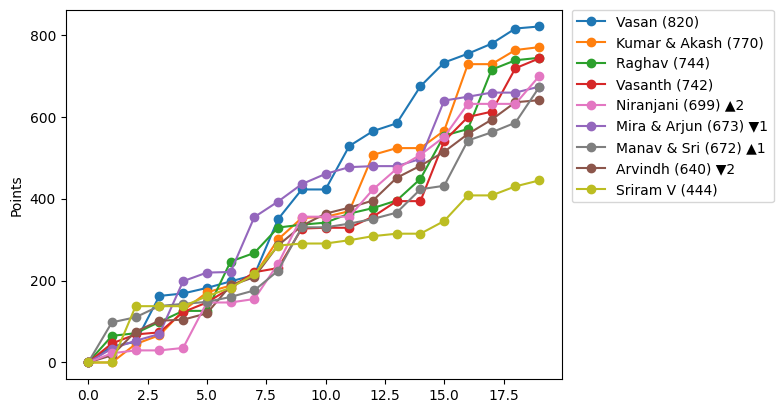

In [ ]:
import matplotlib.pyplot as plt
ax = graph_scores.plot.line(marker='o')
#ax.set_xlabel("Days")
ax.set_ylabel("Points")
# Create legend labels with final scores, sorted by points (descending)
final_scores = graph_scores.iloc[-1]
sorted_cols = final_scores.sort_values(ascending=False).index

# Calculate position changes (if there are at least 2 days of data)
position_changes = {}
if len(graph_scores) >= 2:
    prev_scores = graph_scores.iloc[-2]
    prev_sorted = prev_scores.sort_values(ascending=False).index
    
    # Create position mappings
    prev_positions = {col: idx for idx, col in enumerate(prev_sorted)}
    curr_positions = {col: idx for idx, col in enumerate(sorted_cols)}
    
    # Calculate changes (negative means moved up, positive means moved down)
    for col in sorted_cols:
        if col in prev_positions:
            position_changes[col] = prev_positions[col] - curr_positions[col]
        else:
            position_changes[col] = 0
else:
    # No previous data, all changes are 0
    for col in sorted_cols:
        position_changes[col] = 0

# Get handles and labels from the plot
handles, labels = ax.get_legend_handles_labels()
# Create a mapping of original column names to handles
handle_dict = dict(zip(graph_scores.columns, handles))
# Reorder handles and create new labels based on sorted columns with position change indicators
sorted_handles = [handle_dict[col] for col in sorted_cols]
sorted_labels = []
for col in sorted_cols:
    change = position_changes[col]
    if change > 0:
        # Upward triangle for improvement (will be colored green)
        indicator = f" ▲{change}"
    elif change < 0:
        # Downward triangle for decline (will be colored red)
        indicator = f" ▼{abs(change)}"
    else:
        indicator = ""
    sorted_labels.append(f"{col} ({int(final_scores[col])}){indicator}")

legend = plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.savefig(leaderboard_graph_file, bbox_inches="tight")

In [ ]:
scores_sorted = {k: v for k, v in sorted(scores.items(), key=lambda item: item[1], reverse=True)}
score_msg = str(scores_sorted)

scores_msg_df = pd.DataFrame(
    scores_sorted.items(),
    columns=['Manager', 'Points']
)
leaderboard_table = f'*{day.upper()}*\n```\n{scores_msg_df.to_markdown(index=False)}\n```'
print()
with open(leaderboard_file, 'w') as f:
    f.write(leaderboard_table)